In [1]:
import os, time, random, warnings
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms.functional import rotate as tvrotate
from torchvision import transforms

def set_seed(s: int = 42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")

device : cuda


In [2]:
DATA_DIR   = "/kaggle/input/datasets/vitthal2945/e2e-hidden-symmetries-dataset"
OUT_DIR    = "/kaggle/working/exp3_bidir_spectral"
LATENT_DIM = 16   

EPOCHS_ORACLE = 15
EPOCHS_G      = 60
BATCH_SIZE    = 256
LR_G          = 3e-4

# Loss weights
W_FWD   = 1.0    
W_BWD   = 0.5    
W_INV   = 0.3    
W_CLOSE = 0.4    
W_NORM  = 0.05   

# Fixed-point iterations for approximate g^{-1} (Anderson-style approx via g)
FP_ITERS = 5


TASK1_CKPT = "/kaggle/input/models/vitthal2945/e2e-vaemodel/pytorch/default/1/best_model.pt"

os.makedirs(OUT_DIR, exist_ok=True)
print(f"output → {OUT_DIR}")

output → /kaggle/working/exp3_bidir_spectral


In [3]:
def load_h5(path: str):
    print(f"  loading {os.path.basename(path)} ...", end=" ", flush=True)
    t0 = time.time()
    with h5py.File(path, "r") as f:
        imgs   = torch.from_numpy(f["images"][:].astype("float32")).unsqueeze(1)
        labels = torch.from_numpy(f["labels"][:].astype("int64"))
        angles = torch.from_numpy(f["angles"][:].astype("int64"))
    imgs = imgs.clamp(0., 1.)
    print(f"done  ({imgs.nbytes/1e6:.0f} MB, {time.time()-t0:.1f}s)")
    return imgs, labels, angles

train_imgs, train_lbls, train_angs = load_h5(os.path.join(DATA_DIR, "rotated_mnist_train.h5"))
test_imgs,  test_lbls,  test_angs  = load_h5(os.path.join(DATA_DIR, "rotated_mnist_test.h5"))

ANGLES  = sorted(train_angs.unique().tolist())
DIGITS  = sorted(train_lbls.unique().tolist())
DIG_MAP = {d: i for i, d in enumerate(DIGITS)}
TARGET  = [a for a in ANGLES if a != 0]

pin = device.type == "cuda"
train_loader = DataLoader(TensorDataset(train_imgs, train_lbls, train_angs),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=pin)
test_loader  = DataLoader(TensorDataset(test_imgs, test_lbls, test_angs),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=pin)
print(f"train: {len(train_imgs):,}   test: {len(test_imgs):,}")

  loading rotated_mnist_train.h5 ... done  (478 MB, 2.8s)
  loading rotated_mnist_test.h5 ... done  (82 MB, 0.5s)
train: 152,400   test: 26,004


In [4]:
class ResBlock(nn.Module):
    def __init__(self, ch, g=8):
        super().__init__()
        g = min(g, ch)
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch), nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch),
        )
        self.act = nn.SiLU()
    def forward(self, x): return self.act(x + self.net(x))

class T1Encoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.stem  = nn.Sequential(nn.Conv2d(1, 32, 4, 2, 1, bias=False), nn.GroupNorm(8, 32),  nn.SiLU())
        self.l1    = nn.Sequential(ResBlock(32),  nn.Conv2d(32,  64, 4, 2, 1, bias=False), nn.GroupNorm(8, 64),  nn.SiLU())
        self.l2    = nn.Sequential(ResBlock(64),  nn.Conv2d(64, 128, 3, 2, 1, bias=False), nn.GroupNorm(8, 128), nn.SiLU())
        self.l3    = ResBlock(128)
        self.fc    = nn.Sequential(nn.Flatten(), nn.Linear(128*4*4, 512), nn.SiLU())
        self.fc_mu = nn.Linear(512, ld)
        self.fc_lv = nn.Linear(512, ld)
    def forward(self, x):
        h = self.l3(self.l2(self.l1(self.stem(x))))
        h = self.fc(h)
        return self.fc_mu(h), self.fc_lv(h)

class T1Decoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(ld, 512), nn.SiLU(), nn.Linear(512, 128*4*4), nn.SiLU())
        self.u1 = nn.Sequential(ResBlock(128), nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1), nn.GroupNorm(8, 64),  nn.SiLU())
        self.u2 = nn.Sequential(ResBlock(64),  nn.ConvTranspose2d(64,  32, 4, 2, 1),                  nn.GroupNorm(8, 32),  nn.SiLU())
        self.u3 = nn.Sequential(ResBlock(32),  nn.ConvTranspose2d(32,   1, 4, 2, 3),                  nn.Sigmoid())
    def forward(self, z): return self.u3(self.u2(self.u1(self.fc(z).view(-1, 128, 4, 4))))

class Task1VAE(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.encoder = T1Encoder(ld)
        self.decoder = T1Decoder(ld)
    def reparameterise(self, mu, lv):
        return mu + torch.randn_like(mu) * (0.5 * lv).exp() if self.training else mu
    def encode(self, x): return self.encoder(x)
    def decode(self, z): return self.decoder(z)
    def forward(self, x):
        mu, lv = self.encoder(x)
        return self.decoder(self.reparameterise(mu, lv)), mu, lv

vae = Task1VAE(LATENT_DIM).to(device)
if os.path.exists(TASK1_CKPT):
    ckpt = torch.load(TASK1_CKPT, map_location=device, weights_only=False)
    vae.load_state_dict(ckpt["model"])
    print(f"Task-1 VAE loaded (epoch {ckpt['epoch']})")
else:
    print("⚠ Task-1 checkpoint not found — using random VAE weights (replace TASK1_CKPT)")

vae.eval()
for p in vae.parameters():
    p.requires_grad = False

Task-1 VAE loaded (epoch 47)


In [5]:
class Oracle(nn.Module):
    def __init__(self, ld, nc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(ld, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 32),  nn.ReLU(),
            nn.Linear(32, nc),
        )
    def forward(self, z): return self.net(z)

psi = Oracle(LATENT_DIM, len(DIGITS)).to(device)
opt_psi = torch.optim.Adam(psi.parameters(), lr=1e-3)
print(f"\nTraining Oracle for {EPOCHS_ORACLE} epochs …")

for ep in range(1, EPOCHS_ORACLE + 1):
    psi.train(); correct = total = 0
    for imgs, lbls, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        cls  = torch.tensor([DIG_MAP[l.item()] for l in lbls], device=device)
        with torch.no_grad():
            mu, _ = vae.encode(imgs)
        opt_psi.zero_grad()
        logits = psi(mu)
        F.cross_entropy(logits, cls).backward()
        opt_psi.step()
        correct += (logits.detach().argmax(1) == cls).sum().item()
        total   += imgs.size(0)
    if ep % 5 == 0 or ep == 1:
        print(f"  Oracle ep {ep:2d}/{EPOCHS_ORACLE}  acc={correct/total:.4f}")

psi.eval()
for p in psi.parameters():
    p.requires_grad = False
print("Oracle frozen.")


Training Oracle for 15 epochs …
  Oracle ep  1/15  acc=0.9849
  Oracle ep  5/15  acc=0.9886
  Oracle ep 10/15  acc=0.9888
  Oracle ep 15/15  acc=0.9892
Oracle frozen.


In [6]:
def sn_linear(in_f: int, out_f: int) -> nn.Linear:
    """Spectral-normalized linear layer. σ_max(W) ≤ 1 by power iteration."""
    return nn.utils.spectral_norm(nn.Linear(in_f, out_f))

class SpectralEquivariantMLP(nn.Module):
    """
    Spectrally-normalized MLP for forward (+30°) latent step.
    Output is the *displacement* δz = g(z), so z_hat = z + δz.

    Spectral norm ensures:
      ||g(z1) - g(z2)|| ≤ L · ||z1 - z2||  with L < 1
    This makes g a contraction in the displacement space and guarantees
    that the fixed-point iteration for g^{-1} converges.
    """
    def __init__(self, ld: int, hidden: int = 256):
        super().__init__()
        self.layers = nn.Sequential(
            sn_linear(ld, hidden),      nn.LayerNorm(hidden), nn.GELU(),
            sn_linear(hidden, hidden),  nn.LayerNorm(hidden), nn.GELU(),
            sn_linear(hidden, hidden),  nn.LayerNorm(hidden), nn.GELU(),
            sn_linear(hidden, ld),
        )
        # small output init — start near identity transform
        nn.init.uniform_(self.layers[-1].weight_orig, -0.01, 0.01)
        nn.init.zeros_(self.layers[-1].bias)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """Returns displacement δz; call z + g(z) for the mapped point."""
        return self.layers(z)

    @torch.no_grad()
    def approx_inverse(self, z_target: torch.Tensor, n_iters: int = 5) -> torch.Tensor:
        """
        Fixed-point approximation for g^{-1}(z_target):
            Given y = z + g(z), solve for z.
            Fixed-point iteration: z_{k+1} = y - g(z_k)
            Converges when ||∂g/∂z|| < 1 (guaranteed by spectral norm).
        Returns z_0 such that z_0 + g(z_0) ≈ z_target.
        """
        z_k = z_target.clone()
        for _ in range(n_iters):
            z_k = z_target - self.forward(z_k)
        return z_k

g = SpectralEquivariantMLP(LATENT_DIM).to(device)
print(f"\nSpectral Equivariant MLP params: {sum(p.numel() for p in g.parameters()):,}")


Spectral Equivariant MLP params: 141,584


In [7]:
def step_fwd(z: torch.Tensor) -> torch.Tensor:
    """z + g(z): one +30° latent step."""
    return z + g(z)

def step_bwd(z: torch.Tensor) -> torch.Tensor:
    """Approximate g^{-1}: one -30° latent step via fixed-point."""
    return g.approx_inverse(z, n_iters=FP_ITERS)

def orbit_fwd(z: torch.Tensor, n: int) -> torch.Tensor:
    for _ in range(n): z = step_fwd(z)
    return z

In [8]:
print("\n── Phase 2: Bi-Directional Spectrally-Normalized MLP ─────────────")

opt_g   = torch.optim.AdamW(g.parameters(), lr=LR_G, weight_decay=1e-5)
sched_g = torch.optim.lr_scheduler.CosineAnnealingLR(opt_g, T_max=EPOCHS_G)

history = {k: [] for k in ["fwd", "bwd", "inv", "close", "norm", "total", "val_90"]}
best_val = float("inf")

for ep in range(1, EPOCHS_G + 1):
    g.train()
    acc = {k: 0.0 for k in ["fwd", "bwd", "inv", "close", "norm"]}
    n_batches = 0

    for imgs, _, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)

        img_p30 = tvrotate(imgs,  30., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        img_m30 = tvrotate(imgs, -30., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        img_p90 = tvrotate(imgs,  90., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])

        with torch.no_grad():
            z0,   _ = vae.encode(imgs)
            z_p30, _ = vae.encode(img_p30)
            z_m30, _ = vae.encode(img_m30)
            z_p90, _ = vae.encode(img_p90)

        opt_g.zero_grad(set_to_none=True)

        # ── L_fwd: forward supervised (+30°) ───────────────────────────────
        z_hat_fwd = step_fwd(z0)
        l_fwd     = F.mse_loss(z_hat_fwd, z_p30)

        # ── L_bwd: backward supervised (-30°) ──────────────────────────────
        # g^{-1}(z0) ≈ z_{-30°}  in the sense that z_{-30°} + g(z_{-30°}) ≈ z0
        # We train g to satisfy: z0 - g^{-1}(z0) ≈ z_{-30°}
        # Fixed-point approx (no grad through inner loop for stability)
        with torch.no_grad():
            z_inv_approx = g.approx_inverse(z0, n_iters=FP_ITERS)
        # Now require with grad: z_inv_approx is close to z_{-30°}
        # Re-evaluate with grad for the loss only (1 iter grad-through)
        z_inv_1step = z0 - g(z_inv_approx)   # 1 step of fixed-point, with grad
        l_bwd       = F.mse_loss(z_inv_1step, z_m30)

        # ── L_inv: inverse consistency  g(g^{-1}(z)) ≈ z ───────────────────
        z_reconstructed = step_fwd(z_inv_approx)
        l_inv           = F.mse_loss(z_reconstructed, z0)

        # ── L_close: 3-step group closure  g^3(z) ≈ z_{90°} ───────────────
        z_3 = orbit_fwd(z0, 3)
        l_close = F.mse_loss(z_3, z_p90)

        # ── L_norm: step-size matching ──────────────────────────────────────
        dz_pred = g(z0).norm(dim=1)
        dz_gt   = (z_p30 - z0).norm(dim=1).detach()
        l_norm  = F.mse_loss(dz_pred, dz_gt)

        loss = (W_FWD   * l_fwd   +
                W_BWD   * l_bwd   +
                W_INV   * l_inv   +
                W_CLOSE * l_close +
                W_NORM  * l_norm)
        loss.backward()
        nn.utils.clip_grad_norm_(g.parameters(), 1.0)
        opt_g.step()

        acc["fwd"]   += l_fwd.item()
        acc["bwd"]   += l_bwd.item()
        acc["inv"]   += l_inv.item()
        acc["close"] += l_close.item()
        acc["norm"]  += l_norm.item()
        n_batches += 1

    sched_g.step()
    for k in acc: acc[k] /= n_batches
    total = (W_FWD * acc["fwd"] + W_BWD * acc["bwd"] +
             W_INV * acc["inv"] + W_CLOSE * acc["close"] + W_NORM * acc["norm"])

    # validation: 3-step MSE at 90°
    g.eval()
    with torch.no_grad():
        pool = (test_angs == 0).nonzero(as_tuple=True)[0][:300]
        x_val = test_imgs[pool].to(device)
        z_val, _ = vae.encode(x_val)
        x90_val  = tvrotate(x_val, 90., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        z_gt90, _ = vae.encode(x90_val)
        z_pred90  = orbit_fwd(z_val, 3)
        val_90    = F.mse_loss(z_pred90, z_gt90).item()
    g.train()

    for k in acc: history[k].append(acc[k])
    history["total"].append(total)
    history["val_90"].append(val_90)

    if val_90 < best_val:
        best_val = val_90
        torch.save({"g": g.state_dict(), "psi": psi.state_dict(), "epoch": ep,
                    "val_90": best_val}, os.path.join(OUT_DIR, "best_model.pt"))
        tag = "  ★"
    else:
        tag = ""

    if ep % 5 == 0 or ep == 1 or tag:
        print(f"  ep {ep:3d}/{EPOCHS_G}  fwd={acc['fwd']:.5f}  bwd={acc['bwd']:.5f}  "
              f"inv={acc['inv']:.5f}  close={acc['close']:.5f}  val_90={val_90:.5f}{tag}")

ck = torch.load(os.path.join(OUT_DIR, "best_model.pt"), weights_only=False)
g.load_state_dict(ck["g"]); psi.load_state_dict(ck["psi"])
g.eval()
print(f"Best model loaded (epoch {ck['epoch']}, val_90={ck['val_90']:.5f})")


── Phase 2: Bi-Directional Spectrally-Normalized MLP ─────────────
  ep   1/60  fwd=0.00370  bwd=0.00800  inv=0.00220  close=0.01057  val_90=0.00207  ★
  ep   2/60  fwd=0.00162  bwd=0.00399  inv=0.00167  close=0.00221  val_90=0.00144  ★
  ep   5/60  fwd=0.00121  bwd=0.00278  inv=0.00110  close=0.00155  val_90=0.00173
  ep   6/60  fwd=0.00118  bwd=0.00272  inv=0.00103  close=0.00152  val_90=0.00123  ★
  ep   9/60  fwd=0.00108  bwd=0.00248  inv=0.00098  close=0.00144  val_90=0.00113  ★
  ep  10/60  fwd=0.00105  bwd=0.00242  inv=0.00100  close=0.00140  val_90=0.00120
  ep  11/60  fwd=0.00102  bwd=0.00235  inv=0.00096  close=0.00133  val_90=0.00104  ★
  ep  14/60  fwd=0.00097  bwd=0.00237  inv=0.00099  close=0.00128  val_90=0.00102  ★
  ep  15/60  fwd=0.00095  bwd=0.00228  inv=0.00097  close=0.00123  val_90=0.00116
  ep  18/60  fwd=0.00089  bwd=0.00202  inv=0.00085  close=0.00115  val_90=0.00094  ★
  ep  19/60  fwd=0.00087  bwd=0.00202  inv=0.00090  close=0.00113  val_90=0.00091  ★
  ep  

In [9]:
@torch.no_grad()
def evaluate():
    pool = (test_angs == 0).nonzero(as_tuple=True)[0][:500]
    x0   = test_imgs[pool].to(device)
    z0, _ = vae.encode(x0)

    # M1 — per-angle latent MSE (forward rollout)
    m1_per = {}
    for theta in TARGET:
        xr = tvrotate(x0, float(theta), interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        z_gt, _ = vae.encode(xr)
        n_steps  = int(round(theta / 30))
        z_pred   = orbit_fwd(z0, n_steps)
        m1_per[theta] = F.mse_loss(z_pred, z_gt).item()
    m1_mean = float(np.mean(list(m1_per.values())))

    # M2 — oracle drift after 360°
    z360  = orbit_fwd(z0, 12)
    p0    = torch.softmax(psi(z0), dim=1)
    m2    = F.mse_loss(torch.softmax(psi(z360), dim=1), p0).item()

    # M3 — step norm
    dz   = g(z0)
    m3m  = dz.norm(dim=1).mean().item()
    m3s  = dz.norm(dim=1).std().item()

    # M4 — inverse consistency: g(g^{-1}(z)) ≈ z
    z_inv = g.approx_inverse(z0, n_iters=FP_ITERS)
    m4    = F.mse_loss(step_fwd(z_inv), z0).item()

    # M5 — backward accuracy (-30°)
    x_m30 = tvrotate(x0, -30., interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
    z_m30, _ = vae.encode(x_m30)
    z_inv_step = z0 - g(g.approx_inverse(z0, n_iters=FP_ITERS))
    m5    = F.mse_loss(z_inv_step, z_m30).item()

    # M6 — Lipschitz estimate (spectral norm product)
    lip = 1.0
    for m in g.layers:
        if isinstance(m, nn.Linear):
            try:
                sigma = torch.linalg.svdvals(m.weight)[0].item()
                lip *= sigma
            except Exception:
                pass

    return m1_per, m1_mean, m2, m3m, m3s, m4, m5, lip

m1_per, m1_mean, m2, m3m, m3s, m4, m5, lip = evaluate()
print("\n══════════════ FINAL METRICS ══════════════")
print(f"M1 Latent MSE (mean)           : {m1_mean:.5f}")
for theta, v in m1_per.items():
    print(f"     θ={theta:4d}°  →  {v:.5f}")
print(f"M2 Oracle drift (360°)         : {m2:.5f}")
print(f"M3 Step norm  mean ± std       : {m3m:.4f} ± {m3s:.4f}")
print(f"M4 Inverse consistency g∘g⁻¹  : {m4:.5f}")
print(f"M5 Backward accuracy (-30°)    : {m5:.5f}")
print(f"M6 Lipschitz bound (product)   : {lip:.4f}")
print("═══════════════════════════════════════════")

np.save(os.path.join(OUT_DIR, "metrics.npy"), {
    "exp": "EXP3_BIDIR_SPECTRAL_MLP",
    "m1_per_angle": m1_per, "m1_mean": m1_mean,
    "m2_oracle_drift": m2,
    "m3_norm_mean": m3m, "m3_norm_std": m3s,
    "m4_inverse_consistency": m4,
    "m5_backward_accuracy": m5,
    "m6_lipschitz_bound": lip,
    "history": history,
}, allow_pickle=True)


══════════════ FINAL METRICS ══════════════
M1 Latent MSE (mean)           : 0.00093
     θ=  30°  →  0.00076
     θ=  60°  →  0.00062
     θ=  90°  →  0.00054
     θ= 120°  →  0.00089
     θ= 150°  →  0.00069
     θ= 180°  →  0.00067
     θ= 210°  →  0.00166
     θ= 240°  →  0.00105
     θ= 270°  →  0.00081
     θ= 300°  →  0.00114
     θ= 330°  →  0.00144
M2 Oracle drift (360°)         : 0.00159
M3 Step norm  mean ± std       : 0.8487 ± 0.2919
M4 Inverse consistency g∘g⁻¹  : 0.00121
M5 Backward accuracy (-30°)    : 0.00144
M6 Lipschitz bound (product)   : 1.0001
═══════════════════════════════════════════


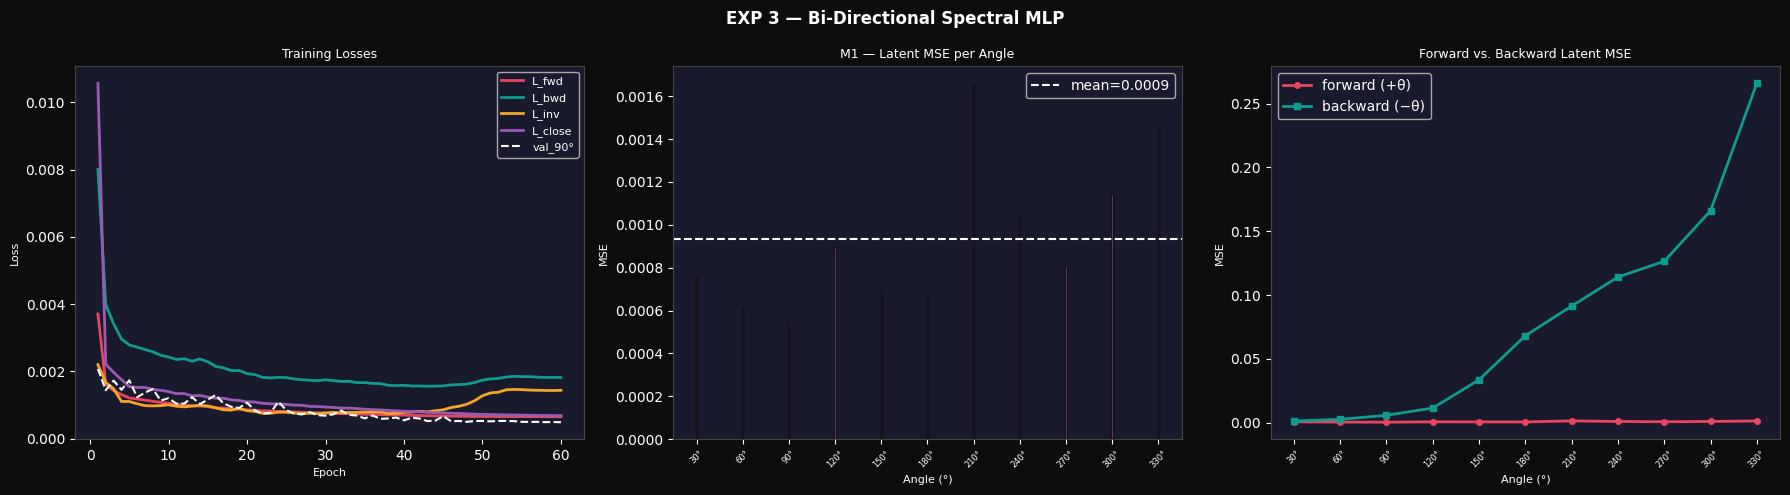

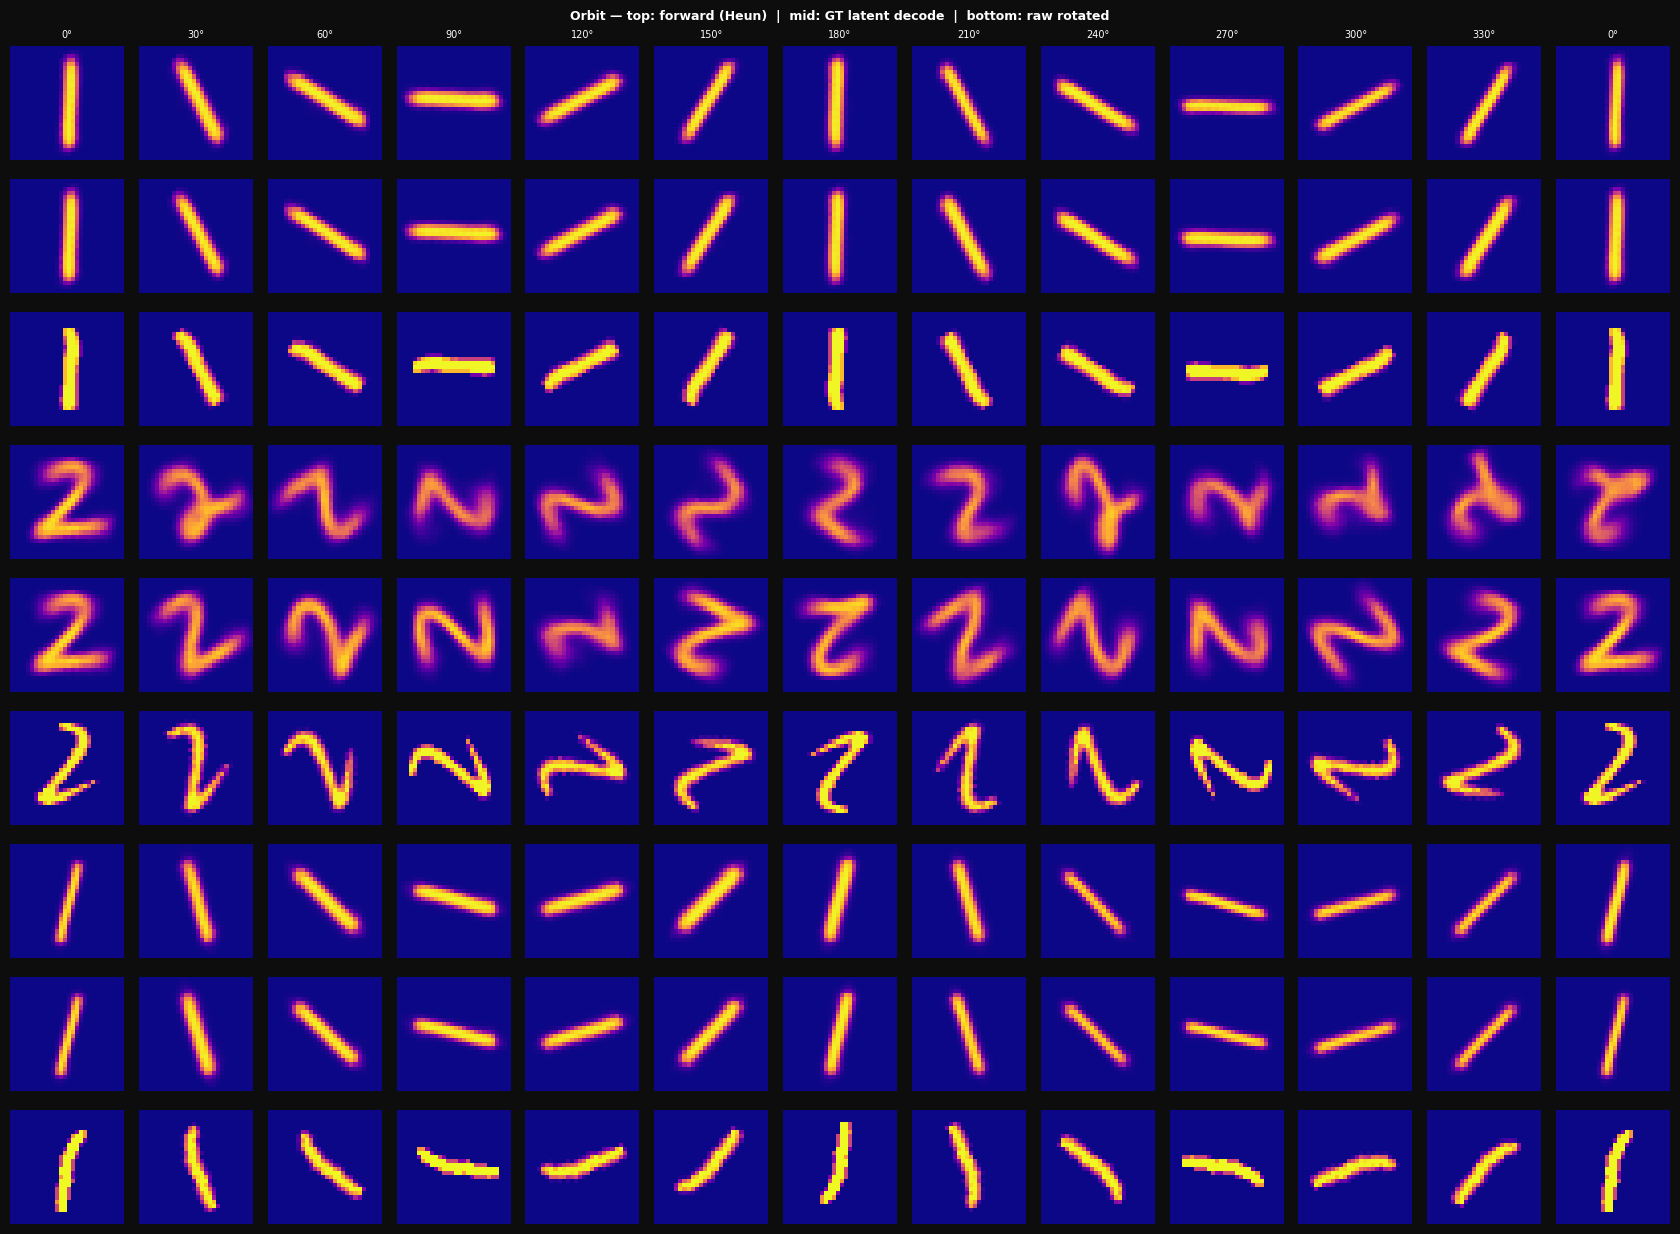


✅ EXP 3 (Bi-Directional Spectral MLP) complete
   M1=0.00093  M2=0.00159  M4_inv=0.00121  Lip=1.0001


In [10]:
DARK = "#0d0d0d"; PANEL = "#1a1a2e"

def _ax(ax, title="", xl="", yl=""):
    ax.set_facecolor(PANEL); ax.tick_params(colors="white")
    for s in ax.spines.values(): s.set_edgecolor("#444")
    if title: ax.set_title(title, color="white", fontsize=9)
    if xl:    ax.set_xlabel(xl, color="white", fontsize=8)
    if yl:    ax.set_ylabel(yl, color="white", fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=DARK)
fig.suptitle("EXP 3 — Bi-Directional Spectral MLP", color="white", fontsize=12, fontweight="bold")

ep_ax = range(1, EPOCHS_G + 1)
_ax(axes[0], "Training Losses", "Epoch", "Loss")
axes[0].plot(ep_ax, history["fwd"],    color="#e94560", lw=2, label="L_fwd")
axes[0].plot(ep_ax, history["bwd"],    color="#0f9b8e", lw=2, label="L_bwd")
axes[0].plot(ep_ax, history["inv"],    color="#f5a623", lw=2, label="L_inv")
axes[0].plot(ep_ax, history["close"],  color="#9b59b6", lw=2, label="L_close")
axes[0].plot(ep_ax, history["val_90"], color="white",   lw=1.5, ls="--", label="val_90°")
axes[0].legend(facecolor=PANEL, labelcolor="white", fontsize=8)

_ax(axes[1], "M1 — Latent MSE per Angle", "Angle (°)", "MSE")
axes[1].bar(list(m1_per.keys()), list(m1_per.values()),
            color="#9b59b6", alpha=0.85, edgecolor=DARK)
axes[1].axhline(m1_mean, color="white", ls="--", lw=1.5, label=f"mean={m1_mean:.4f}")
axes[1].set_xticks(list(m1_per.keys()))
axes[1].set_xticklabels([f"{a}°" for a in m1_per.keys()], color="white", fontsize=6, rotation=45)
axes[1].legend(facecolor=PANEL, labelcolor="white")

# Forward vs backward symmetry check
with torch.no_grad():
    pool = (test_angs == 0).nonzero(as_tuple=True)[0][:300]
    z_chk = test_imgs[pool].to(device)
    z_chk, _ = vae.encode(z_chk)
    fwd_err, bwd_err = [], []
    for theta in range(30, 360, 30):
        xr_p = tvrotate(test_imgs[pool].to(device), float(theta),
                        interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        xr_m = tvrotate(test_imgs[pool].to(device), float(-theta),
                        interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])
        zp, _ = vae.encode(xr_p); zm, _ = vae.encode(xr_m)
        z_pred_p = orbit_fwd(z_chk, theta // 30)
        z_inv_n  = z_chk.clone()
        for _ in range(theta // 30):
            z_inv_n = z_inv_n - g(g.approx_inverse(z_inv_n, FP_ITERS))
        fwd_err.append(F.mse_loss(z_pred_p, zp).item())
        bwd_err.append(F.mse_loss(z_inv_n, zm).item())

thetas_plot = list(range(30, 360, 30))
_ax(axes[2], "Forward vs. Backward Latent MSE", "Angle (°)", "MSE")
axes[2].plot(thetas_plot, fwd_err, color="#e94560", lw=2, marker="o", ms=4, label="forward (+θ)")
axes[2].plot(thetas_plot, bwd_err, color="#0f9b8e", lw=2, marker="s", ms=4, label="backward (−θ)")
axes[2].legend(facecolor=PANEL, labelcolor="white")
axes[2].set_xticks(thetas_plot)
axes[2].set_xticklabels([f"{t}°" for t in thetas_plot], color="white", fontsize=6, rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "results.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()

# ── orbit: forward rows + backward rows ──────────────────────────────────────
@torch.no_grad()
def plot_orbit(n_samples: int = 3):
    pool = (test_angs == 0).nonzero(as_tuple=True)[0][:n_samples]
    x0   = test_imgs[pool].to(device)
    z0, _ = vae.encode(x0)

    n_show = 12
    fig, axes = plt.subplots(n_samples * 3, n_show + 1,
                              figsize=((n_show + 1) * 1.3, n_samples * 4.2), facecolor=DARK)
    fig.suptitle("Orbit — top: forward (Heun)  |  mid: GT latent decode  |  bottom: raw rotated",
                 color="white", fontsize=9, fontweight="bold")

    for row in range(n_samples):
        z = z0[row:row+1].clone()
        for col in range(n_show + 1):
            angle = (col * 30) % 360
            xr = x0[row:row+1] if angle == 0 else tvrotate(
                x0[row:row+1], float(angle),
                interpolation=transforms.InterpolationMode.BILINEAR, fill=[0.])

            pred = vae.decode(z).clamp(0., 1.).cpu().squeeze().numpy()
            axes[row*3,   col].imshow(pred, cmap="plasma", vmin=0, vmax=1)
            axes[row*3,   col].axis("off")

            z_gt, _ = vae.encode(xr)
            gt_dec  = vae.decode(z_gt).clamp(0., 1.).cpu().squeeze().numpy()
            axes[row*3+1, col].imshow(gt_dec, cmap="plasma", vmin=0, vmax=1)
            axes[row*3+1, col].axis("off")

            axes[row*3+2, col].imshow(xr.cpu().squeeze().numpy(), cmap="plasma", vmin=0, vmax=1)
            axes[row*3+2, col].axis("off")

            if row == 0:
                axes[0, col].set_title(f"{angle}°", color="white", fontsize=7)
            z = step_fwd(z)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "orbit.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()

plot_orbit()

print(f"\n✅ EXP 3 (Bi-Directional Spectral MLP) complete")
print(f"   M1={m1_mean:.5f}  M2={m2:.5f}  M4_inv={m4:.5f}  Lip={lip:.4f}")